# Single‑Qubit Gates  
### Rotations, Unitary Operators, and Bloch Sphere Geometry

In this notebook, we study the fundamental building blocks of quantum computing:  
**single‑qubit gates**.

A single‑qubit gate is a 2×2 unitary matrix acting on a qubit state:

$$\ket{\psi_{\text{out}}} = U \ket{\psi_{\text{in}}} \quad, \quad U^\dagger U = I.$$

Although this definition is purely algebraic, the key insight is that:

**Every single‑qubit gate corresponds to a rotation of the Bloch sphere.**

This geometric interpretation is extremely powerful.  
It allows us to understand quantum gates not only as matrices, but as **rotations in 3D space**.

---

## What we will do in this notebook

1. **Define the standard single‑qubit gates**  
   - Pauli gates: X, Y, Z  
   - Hadamard gate H  
   - Phase gates: S and T  
   - Rotation gates: $R_x(\theta), R_y(\theta), R_z(\theta)$

2. **Apply these gates to quantum states**  
   - Using matrix multiplication  
   - Using Bloch vectors  
   - Comparing algebraic and geometric effects

3. **Visualize the action of gates on the Bloch sphere**  
   - Before/after state vectors  
   - Rotations around x, y, z axes  
   - Axis‑swapping behavior of the Hadamard gate

---

## Why this notebook matters

This notebook connects three essential layers of understanding:

- **Quantum mechanics**  
  Gates are generated by exponentials of Pauli matrices.

- **Quantum computing**  
  Gates form the basic operations of quantum circuits.

- **Geometry**  
  Gates correspond to rotations of the Bloch sphere.

Mastering this correspondence is crucial for understanding how quantum algorithms manipulate information.

This notebook is both a **learning tool** (for me) and a **demonstration of competence**.  
It shows the ability to move fluently between algebra, physics, and visualization — a key skill in quantum computing.


## 1 — Standard Single‑Qubit Gates  
### Algebraic Definitions and Geometric Interpretation

Single‑qubit gates are 2×2 unitary matrices acting on a qubit state:

$$\ket{\psi_{\text{out}}} = U \ket{\psi_{\text{in}}}.$$

Although this definition is algebraic, every single‑qubit gate has a **geometric meaning**:  
it corresponds to a **rotation of the Bloch sphere** around some axis by some angle.

This section introduces the most important gates used in quantum computing and explains both:

- their **matrix form**
- their **geometric action** on the Bloch sphere.

---

## 1.1 Pauli Gates (X, Y, Z)

The Pauli matrices form the fundamental generators of single‑qubit rotations.

### X gate  

$$X = \sigma_x =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$


- flips $\ket0 \leftrightarrow \ket1$  
- rotation of $\pi$ around the x‑axis  
- classical NOT gate analog  

### Y gate  

$$Y = \sigma_y =
\begin{pmatrix}
0 & -i \\
i & 0
\end{pmatrix}
$$


- rotation of $\pi$ around the y‑axis  
- introduces a relative phase  

### Z gate  

$$Z = \sigma_z =
\begin{pmatrix}
1 & 0 \\
0 & -1
\end{pmatrix}
$$


- leaves $\ket0$ unchanged  
- flips the phase of $\ket1$ 
- rotation of π around the z‑axis  

These three gates correspond exactly to the **x, y, z axes** of the Bloch sphere.

---

## 1.2 Hadamard Gate (H)

The Hadamard gate is one of the most important gates in quantum computing.

$$H = \frac{1}{\sqrt{2}}
\begin{pmatrix}
1 & 1 \\
1 & -1
\end{pmatrix}
$$

It performs a rotation that:

- maps the z‑axis to the x‑axis  
- creates superposition from $\ket0$  
- enables interference in quantum algorithms  

Geometrically, H is a rotation around the axis:

$$\hat{n} = \frac{1}{\sqrt{2}}(1, 0, 1)$$

which lies halfway between the x‑ and z‑axes.

---

## 1.3 Phase Gates (S and T)

These gates add a controlled phase to the $\ket1$ component.

### S gate  

$$S =
\begin{pmatrix}
1 & 0 \\
0 & i
\end{pmatrix}
= R_z(\pi/2)
$$

### T gate  


$$T =
\begin{pmatrix}
1 & 0 \\
0 & e^{i\pi/4}
\end{pmatrix}
= R_z(\pi/4)
$$

They do **not** change populations — only phases.  
On the Bloch sphere, they correspond to **rotations around the z‑axis**.

---

## 1.4 Rotation Gates (Rx, Ry, Rz)

These are the continuous versions of the Pauli gates.


$$R_x(\theta) = e^{-i\theta\sigma_x/2}, \quad
R_y(\theta) = e^{-i\theta\sigma_y/2}, \quad
R_z(\theta) = e^{-i\theta\sigma_z/2}.
$$

They represent **arbitrary rotations** around the x, y, and z axes.

These gates are essential for:

- quantum control  
- Hamiltonian simulation  
- Bloch sphere visualization  
- understanding how gates manipulate qubit states  


In [20]:
import numpy as np
from utils import *



# =========================================================
# 1. Pauli Gates (X, Y, Z)
# =========================================================
# These are the fundamental generators of SU(2).
# They correspond to 180° rotations around the x, y, z axes
# of the Bloch sphere.

X = np.array([[0, 1],
              [1, 0]], dtype=complex)

Y = np.array([[0, -1j],
              [1j,  0]], dtype=complex)

Z = np.array([[1,  0],
              [0, -1]], dtype=complex)


# =========================================================
# 2. Hadamard Gate (H)
# =========================================================
# The Hadamard gate is NOT a Pauli matrix.
# It performs a rotation that maps:
#   |0> → |+>
#   |1> → |->
# It creates superposition and is essential for interference.

H = (1/np.sqrt(2)) * np.array([[1,  1],
                               [1, -1]], dtype=complex)


# =========================================================
# 3. Phase Gates (S and T)
# =========================================================
# These gates add a phase to the |1> component.
# They do NOT change populations (|alpha|^2, |beta|^2).
# Geometrically: rotations around the z-axis.

S = np.array([[1, 0],
              [0, 1j]], dtype=complex)   # = Rz(pi/2)

T = np.array([[1, 0],
              [0, np.exp(1j*np.pi/4)]], dtype=complex)  # = Rz(pi/4)


# =========================================================
# 4. Rotation Gates: Rx(θ), Ry(θ), Rz(θ)
# =========================================================
# These are the continuous versions of X, Y, Z.
# They represent arbitrary rotations around the x, y, z axes.
#
# Formula:
#   R_n(θ) = exp(-i θ/2 * σ_n)
#
# For Pauli matrices, the exponential has a closed form:
#   exp(-i θ/2 σ) = cos(θ/2) I - i sin(θ/2) σ
#
# This is extremely useful for simulation and Bloch sphere visualization.

def Rx(theta):
    """Rotation around the x-axis by angle theta."""
    return np.cos(theta/2) * np.eye(2) - 1j * np.sin(theta/2) * X

def Ry(theta):
    """Rotation around the y-axis by angle theta."""
    return np.cos(theta/2) * np.eye(2) - 1j * np.sin(theta/2) * Y

def Rz(theta):
    """Rotation around the z-axis by angle theta."""
    return np.cos(theta/2) * np.eye(2) - 1j * np.sin(theta/2) * Z


# =========================================================
# 5. Quick sanity check (optional but reassuring)
# =========================================================
# We verify unitarity: U† U = I for each gate.

def is_unitary(U):
    """Check if a matrix U is unitary: U†U = I."""
    I = np.eye(U.shape[0])
    return np.allclose(U.conj().T @ U, I)

print("X unitary:", is_unitary(X))
print("Y unitary:", is_unitary(Y))
print("Z unitary:", is_unitary(Z))
print("H unitary:", is_unitary(H))
print("S unitary:", is_unitary(S))
print("T unitary:", is_unitary(T))
print("Rx(pi/3) unitary:", is_unitary(Rx(np.pi/3)))
print("Ry(pi/3) unitary:", is_unitary(Ry(np.pi/3)))
print("Rz(pi/3) unitary:", is_unitary(Rz(np.pi/3)))


X unitary: True
Y unitary: True
Z unitary: True
H unitary: True
S unitary: True
T unitary: True
Rx(pi/3) unitary: True
Ry(pi/3) unitary: True
Rz(pi/3) unitary: True


## 2 — Applying Gates to Qubit States  
### Algebraic Action, Bloch Vector Transformation, and Geometric Interpretation

Single‑qubit gates act on quantum states in two complementary ways:

1. **Algebraic action on the state vector**  
   A qubit state  
   

$$\ket{\psi} =
   \begin{pmatrix}
   \alpha \\
   \beta
   \end{pmatrix}
   $$

   transforms under a gate $U$ as:
   

$$\ket{\psi_{\text{out}}} = U \ket{\psi_{\text{in}}}.$$

   This is the Schrödinger picture:  
   the state moves, the basis stays fixed.

2. **Geometric action on the Bloch vector**  
   Every pure qubit state has a Bloch vector:
   

 $$\vec{r} = \braket{ \psi | \vec{\sigma} | \psi}.$$


   When a gate $U$ is applied, the Bloch vector undergoes a $3D$ rotation:
   
   $$\vec{r}_{\text{out}} = R \vec{r}_{\text{in}}$$

   where $R \in SO(3)$ is the rotation corresponding to $U$.  
   This is the Heisenberg picture:  
   the coordinate axes rotate, and the state follows that rotation.

---

### Why this matters

Understanding both pictures is essential:

- The **algebraic picture** tells us how amplitudes change.  
- The **geometric picture** tells us how the qubit moves on the Bloch sphere.  

Together, they give a complete understanding of how quantum gates manipulate information.

---

## What we will do in this section

1. **Choose an initial state**  
   For example:
   - $\ket{0}$
   - $\ket{1}$
   - $\ket{+}$
   - $\ket{+i}$
   - or an arbitrary state from $(\theta, \phi)$

2. **Apply a gate**  
   
 $$\ket{\psi_{\text{out}}} = U \ket{\psi_{\text{in}}}.$$


3. **Compute the Bloch vectors**  
   - before the gate  
   - after the gate  

4. **Visualize the transformation**  
   We will plot both points on the Bloch sphere to show the effect of the gate.

 This “before/after” visualization is one of the most intuitive and powerful ways to understand quantum gates.  
 It also demonstrates the geometric nature of single‑qubit operations, which is a key concept in quantum computing.



Initial state:
 [[1.+0.j]
 [0.+0.j]]
After applying gate:
 [[0.70710678+0.j]
 [0.70710678+0.j]]
Bloch vector (before): [0. 0. 1.]
Bloch vector (after):  [1. 0. 0.]


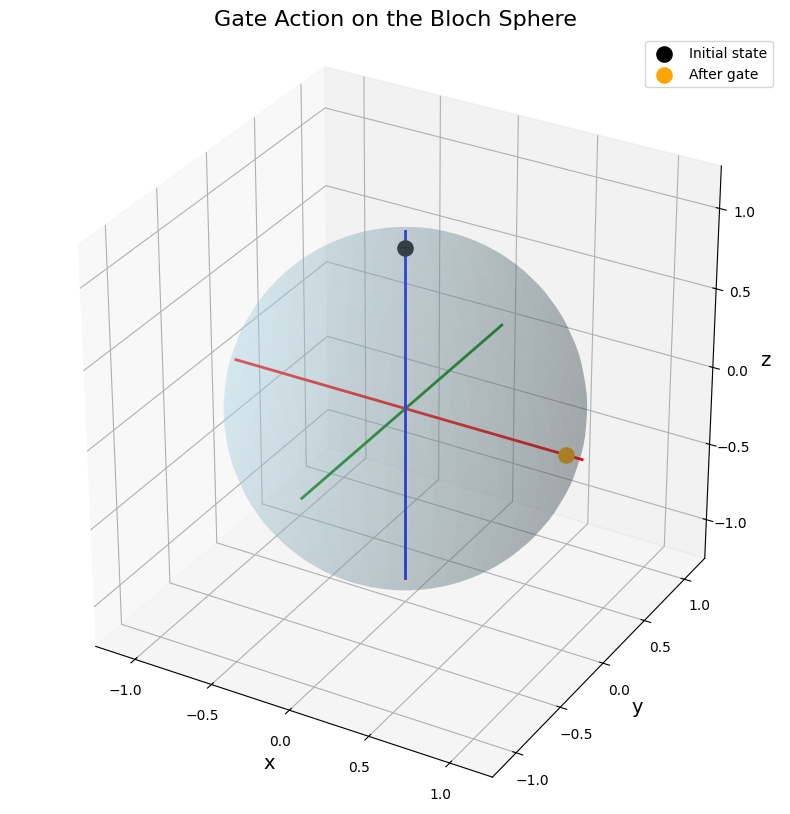

In [21]:
# =========================================================
# Section 2 — Applying Gates to States
# =========================================================
# In this section, we:
# 1. Define a helper function to apply a gate to a state.
# 2. Compute Bloch vectors before and after the gate.
# 3. Visualize the transformation on the Bloch sphere.
# =========================================================

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helper function: apply a gate to a state
# ---------------------------------------------------------
def apply_gate(psi, U):
    """
    Apply a single-qubit gate U to a state |psi>.
    
    Parameters
    ----------
    psi : np.ndarray
        A 2x1 complex column vector representing the qubit state.
    U : np.ndarray
        A 2x2 unitary matrix representing the gate.
    
    Returns
    -------
    psi_out : np.ndarray
        The transformed state U|psi>.
    """
    return U @ psi


# ---------------------------------------------------------
# Example: choose an initial state
# ---------------------------------------------------------
# We can change this to |1>, |+>, |+i>, or any arbitrary state.
ket_0=np.array([[1],
               [0]], dtype=complex)


psi_in = ket_0  # start with |0>

# Choose a gate to apply (example: Hadamard)
U = H

# Apply the gate
psi_out = apply_gate(psi_in, U)

print("Initial state:\n", psi_in)
print("After applying gate:\n", psi_out)


# ---------------------------------------------------------
# Compute Bloch vectors before and after the gate
# ---------------------------------------------------------
r_in  = bloch_vector(psi_in)
r_out = bloch_vector(psi_out)

print("Bloch vector (before):", r_in)
print("Bloch vector (after): ", r_out)


# ---------------------------------------------------------
# Visualization: plot both points on the Bloch sphere
# ---------------------------------------------------------

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Grid for the Bloch sphere surface
theta = np.linspace(0, np.pi, 50)
phi   = np.linspace(0, 2*np.pi, 50)
theta, phi = np.meshgrid(theta, phi)

# Convert spherical → Cartesian coordinates
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)

# --- Draw the Bloch sphere surface ---

ax.plot_surface(x, y, z, color='lightblue', alpha=0.25, linewidth=0)

# --- Draw axes ---
axis_length = 1.1
ax.plot([-axis_length, axis_length], [0, 0], [0, 0], color='red', linewidth=2)
ax.plot([0, 0], [-axis_length, axis_length], [0, 0], color='green', linewidth=2)
ax.plot([0, 0], [0, 0], [-axis_length, axis_length], color='blue', linewidth=2)

# --- Plot the initial state ---
ax.scatter(r_in[0], r_in[1], r_in[2],
           s=120, color='black', label='Initial state')

# --- Plot the final state ---
ax.scatter(r_out[0], r_out[1], r_out[2],
           s=120, color='orange', label='After gate')

# --- Cosmetics ---
ax.set_title("Gate Action on the Bloch Sphere", fontsize=16)
ax.set_xlabel("x", fontsize=14)
ax.set_ylabel("y", fontsize=14)
ax.set_zlabel("z", fontsize=14)
ax.set_box_aspect([1, 1, 1])
ax.legend()

plt.show()


## 3 — Visualizing the Action of Single‑Qubit Gates  
### Bloch Sphere Interpretation of Quantum Operations

In this section, we illustrate how single‑qubit gates act geometrically on the Bloch sphere.

A pure qubit state corresponds to a point on the Bloch sphere:


$$\vec{r} = \braket{\psi | \vec{\sigma} | \psi}.$$


When a gate $U$ is applied, the state transforms as:


$$\ket{\psi_{\text{out}}} = U \ket{\psi_{\text{in}}}$$

and the Bloch vector undergoes a **3D rotation**:

$$\vec{r}_{\text{out}} = R \vec{r}_{\text{in}}$$


where $R \in SO(3)$ is the rotation associated with $U$.

This section provides **visual before/after plots** on the Bloch sphere for several important gates:
- Pauli gates (X, Y, Z)
- Hadamard gate (H)
- Phase gates (S, T)
- Rotation gates $R_x(\theta), R_y(\theta), R_z(\theta)$.

These visualizations help build geometric intuition about how quantum gates manipulate qubit states.


In [22]:
# =========================================================
# Bloch sphere grid (surface)
# =========================================================

theta = np.linspace(0, np.pi, 50)
phi   = np.linspace(0, 2*np.pi, 50)
theta, phi = np.meshgrid(theta, phi)

# Convert spherical → Cartesian
x = np.sin(theta) * np.cos(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(theta)


In [23]:
def plot_bloch_sphere(ax):
    """Draw a Bloch sphere on the given 3D axis."""
    # Sphere surface
    ax.plot_surface(x, y, z, color='lightblue', alpha=0.25, linewidth=0)

    # Axes
    L = 1.1
    ax.plot([-L, L], [0, 0], [0, 0], color='red', linewidth=2)    # x-axis
    ax.plot([0, 0], [-L, L], [0, 0], color='green', linewidth=2)  # y-axis
    ax.plot([0, 0], [0, 0], [-L, L], color='blue', linewidth=2)   # z-axis

    # Cosmetics
    ax.set_box_aspect([1, 1, 1])
    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("y", fontsize=12)
    ax.set_zlabel("z", fontsize=12)
    ax.set_title("Bloch Sphere", fontsize=14)


In [24]:
def plot_state(ax, r, color, label):
    """Plot a Bloch vector r = (rx, ry, rz) on the sphere."""
    ax.scatter(r[0], r[1], r[2], s=120, color=color, label=label)


Example 1: X gate acting on $\ket0$.

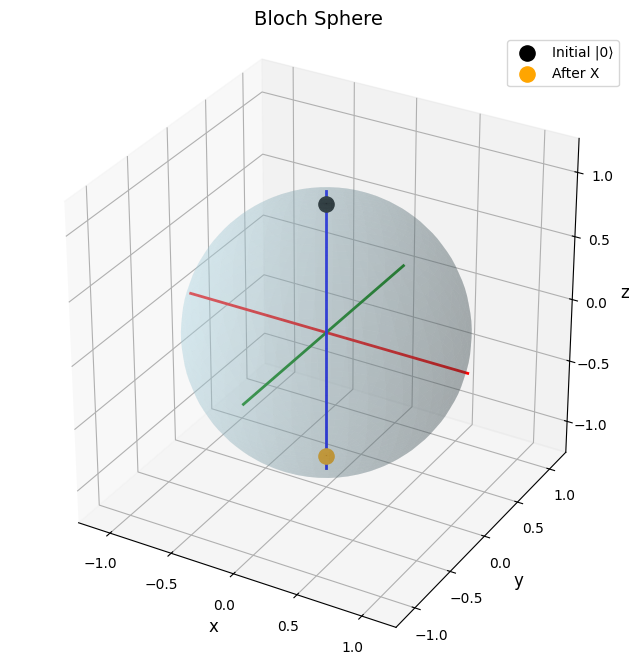

In [25]:
psi_in = ket_0
psi_out = X @ psi_in

r_in  = bloch_vector(psi_in)
r_out = bloch_vector(psi_out)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

plot_bloch_sphere(ax)
plot_state(ax, r_in,  color="black",  label="Initial |0⟩")
plot_state(ax, r_out, color="orange", label="After X")

ax.legend()
plt.show()


Interpretation :  

The X gate perform a $\pi$ rotation around the x-axis, sending $\ket0$ (north pole) to $\ket1$ (south pole).

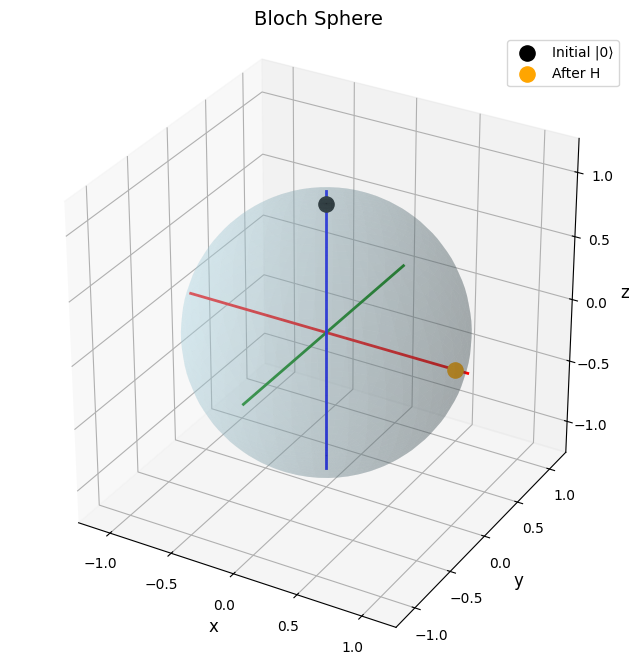

In [26]:
psi_in = ket_0
psi_out = H @ psi_in

r_in  = bloch_vector(psi_in)
r_out = bloch_vector(psi_out)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

plot_bloch_sphere(ax)
plot_state(ax, r_in,  "black",  "Initial |0⟩")
plot_state(ax, r_out, "orange", "After H")

ax.legend()
plt.show()


Interpretation :  

H send $\ket0$ to $\ket+$, means from north pole to the positif x-axis.